In [ ]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', None)


df=  pd.DataFrame(columns=['Lambda_1', 'Lambda_2', 'k_1','k_2','k_3','k_4', 'm', 'w', 'numerator' ,'denominator' , 'Chern-Simons Invariant'])



def cs(l_1,l_2,k_1,k_2,k_3,k_4):
    m = k_1*k_4-k_2*k_3
    w = k_1+k_4
    if (m == 1 or m == -1):
        numer = (( k_4 - k_1 )*l_1*l_2 + k_3*l_2**2 - k_2*l_1**2)*w*m 
        denom = 1+w-w*m*(k_1+k_4)
        if (numer/denom)%1 != 0:
            return [m, w, numer, denom,(numer/denom)%1]


#parameterize table with this
n = 200

for i in range(2*n):
    l1 = -n+i
    l2 = -n-i
    k1 = -n+i

    for j in range(2*n):
        k2 = -n+j
        for k in range(2*n):
            k3 = n-k
            for l in range(2*n):
                k4 = n-l
                
                CS = cs(l1,l2,k1,k2,k3,k4)
                if CS != None:
                    goodlist = [l1,l2,k1,k2,k3,k4,CS[0],CS[1], CS[2], CS[3],CS[4]]
                    df.loc[i] = goodlist

display(df)


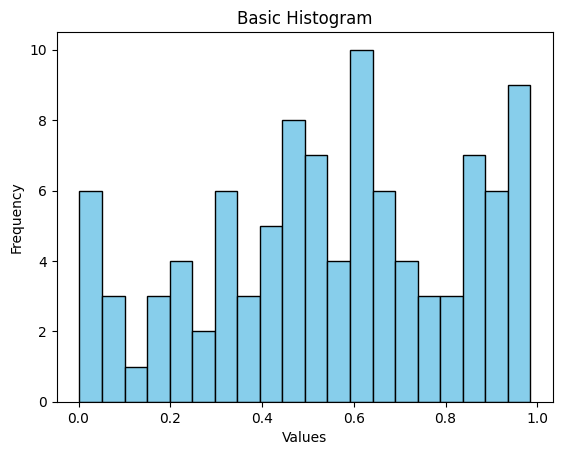

In [30]:
import matplotlib.pyplot as plt

# 2. Create the histogram
plt.hist(df['Chern-Simons Invariant'], bins=20, edgecolor='black', color='skyblue')

# 3. Add labels and show
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram')
plt.show()

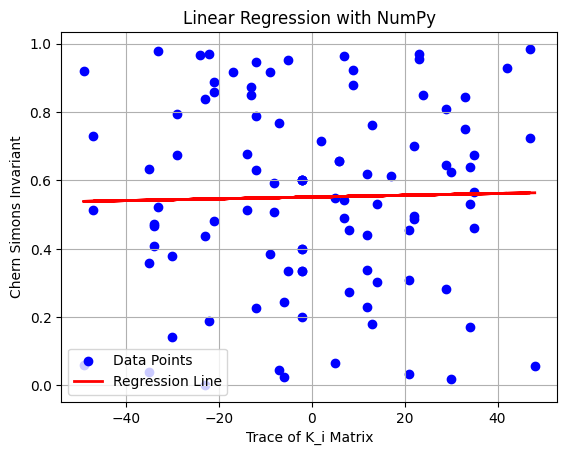

In [32]:

x = df['w']
y = df['Chern-Simons Invariant']

# 3. Add labels and show
slope, intercept = np.polyfit(x, y, 1)
regression_line = slope * x + intercept

# 3. Plotting
plt.scatter(x, y, color="blue", label="Data Points")  # Scatter plot
plt.plot(
    x, regression_line, color="red", linewidth=2, label="Regression Line"
)  # Line plot

# 4. Customization
plt.title("Linear Regression with NumPy")
plt.xlabel("Trace of K_i Matrix")
plt.ylabel("Chern Simons Invariant")
plt.legend()
plt.grid(True)

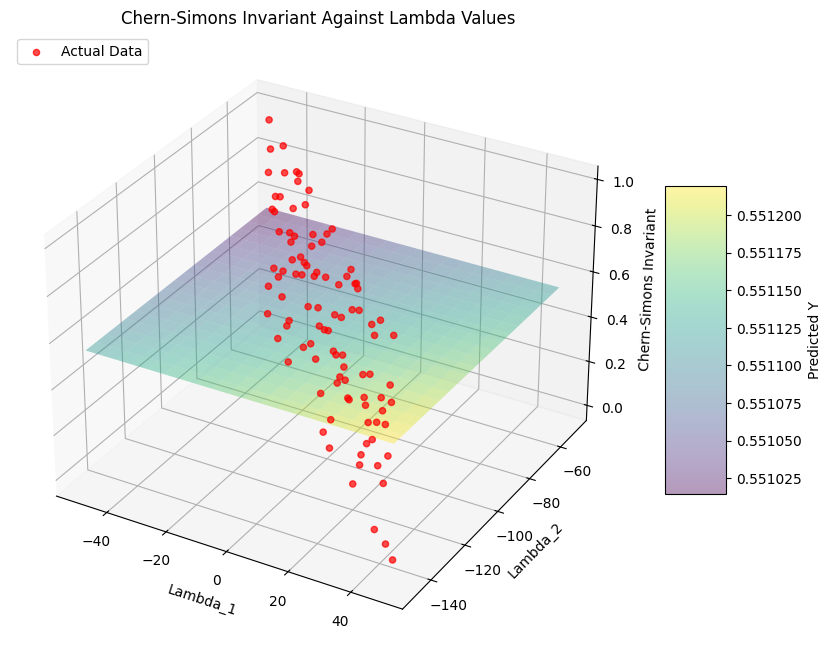

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X1 = df['Lambda_1']
X2 = df['Lambda_2']
# Target variable with some noise added
Y = df['Chern-Simons Invariant']

# 2. Format data and train the Multiple Linear Regression model
X_train = np.vstack((X1, X2)).T
model = LinearRegression()
model.fit(X_train, Y)

# 3. Create a coordinate grid for the regression plane
# Use the minimum and maximum ranges of your actual features
x1_range = np.linspace(X1.min(), X1.max(), 20)
x2_range = np.linspace(X2.min(), X2.max(), 20)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# 4. Use model coefficients to calculate the plane's Z-axis values
# Equation: Z = w1*X1 + w2*X2 + b
w1, w2 = model.coef_
b = model.intercept_
Y_grid = w1 * X1_grid + w2 * X2_grid + b

# 5. Build the 3D Matplotlib Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the individual observed data points
ax.scatter(X1, X2, Y, color='red', marker='o', alpha=0.7, label='Actual Data')

# Plot the predicted regression plane surface
surf = ax.plot_surface(X1_grid, X2_grid, Y_grid, cmap='viridis', alpha=0.4, edgecolor='none')

# Add visual anchors, labels, and colorbars
ax.set_xlabel('Lambda_1')
ax.set_ylabel('Lambda_2')
ax.set_zlabel('Chern-Simons Invariant')
ax.set_title('Chern-Simons Invariant Against Lambda Values')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Predicted Y')
ax.legend(loc='upper left')

# Display the final plot
plt.show()